In [1]:
from neuromaps import NeuroMapFixed
from utils import plot_trajectory
from systems.van_der_pol_rk4 import van_der_pol_rk4, van_der_pol_right_part
from utils import get_attractor_trajectory, plot_trajectory
from utils import plot_compare

import numpy as np

model = NeuroMapFixed.load("checkpoints/model.ckpt")

### Фазовые портреты

Симуляция: 100%|██████████████████████████████████████████| 10000/10000 [00:00<00:00, 14861.15шаг/s]


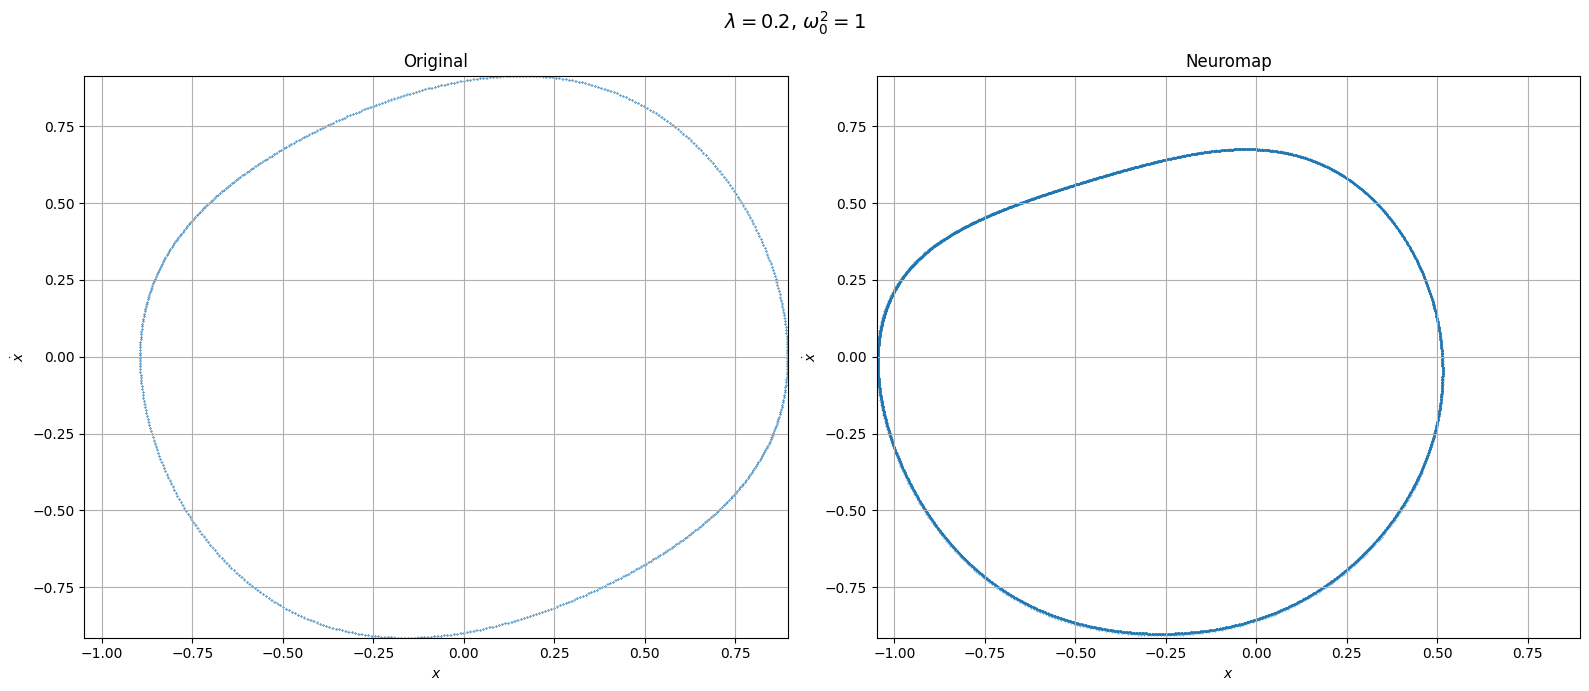

In [2]:
u0 = [0.5, 0.7]
p = [0.2, 1]

nm_traj = model.simulate(u0=u0, p=p, n_steps=10000)[2000:]
ode_traj = get_attractor_trajectory(van_der_pol_rk4, van_der_pol_right_part, u0, p, 0.01, 50, 50, lambda x, y: x[1], lambda x, y: [0, 1])

caption = r'$\lambda=$' + str(p[0]) + r', $\omega_0^2=$' + str(p[1])
plot_compare(ode_traj, nm_traj, caption=caption)

Симуляция: 100%|██████████████████████████████████████████| 10000/10000 [00:00<00:00, 16215.97шаг/s]


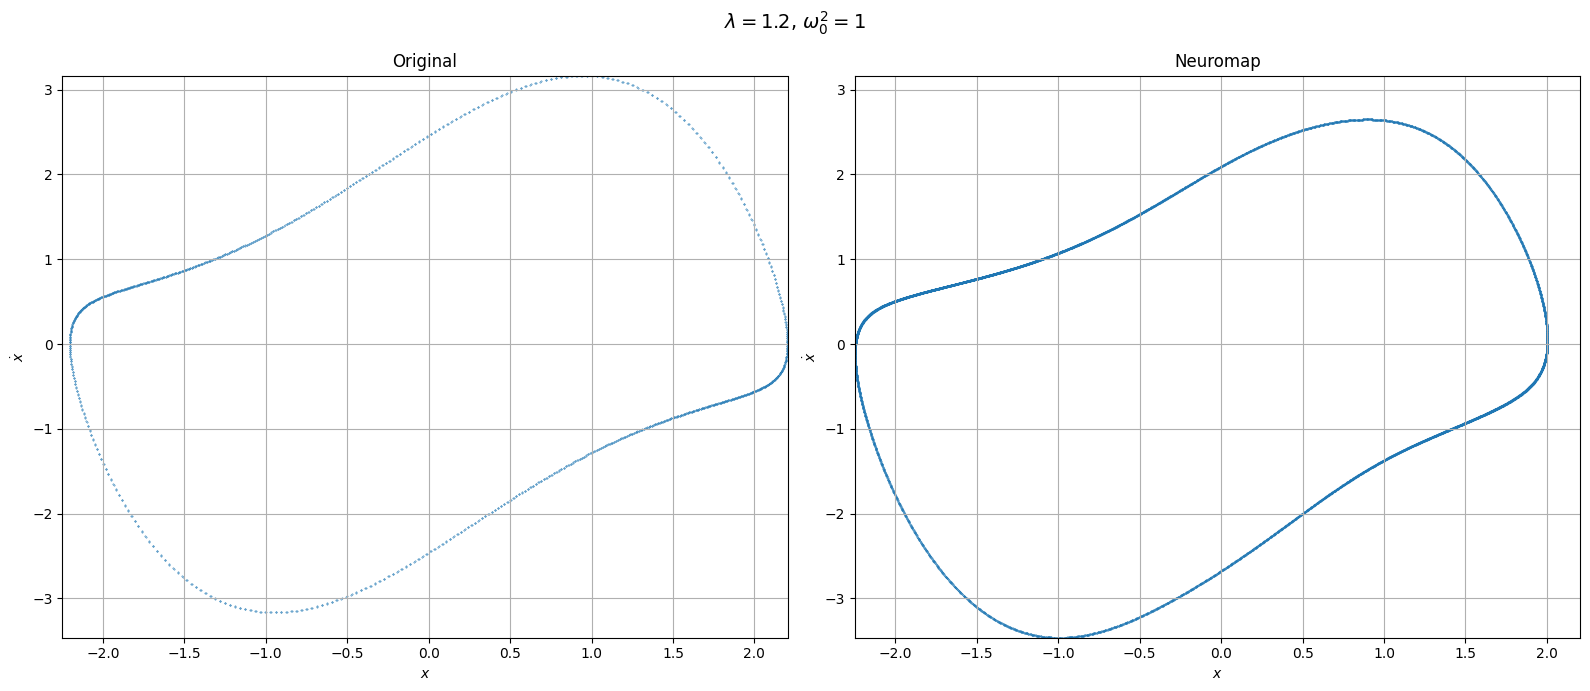

In [3]:
u0 = [0.5, 0.7]
p = [1.2, 1]

nm_traj = model.simulate(u0=u0, p=p, n_steps=10000)[2000:]
ode_traj = get_attractor_trajectory(van_der_pol_rk4, van_der_pol_right_part, u0, p, 0.01, 50, 50, lambda x, y: x[1], lambda x, y: [0, 1])

caption = r'$\lambda=$' + str(p[0]) + r', $\omega_0^2=$' + str(p[1])
plot_compare(ode_traj, nm_traj, caption=caption)

Симуляция: 100%|██████████████████████████████████████████| 10000/10000 [00:00<00:00, 16730.83шаг/s]


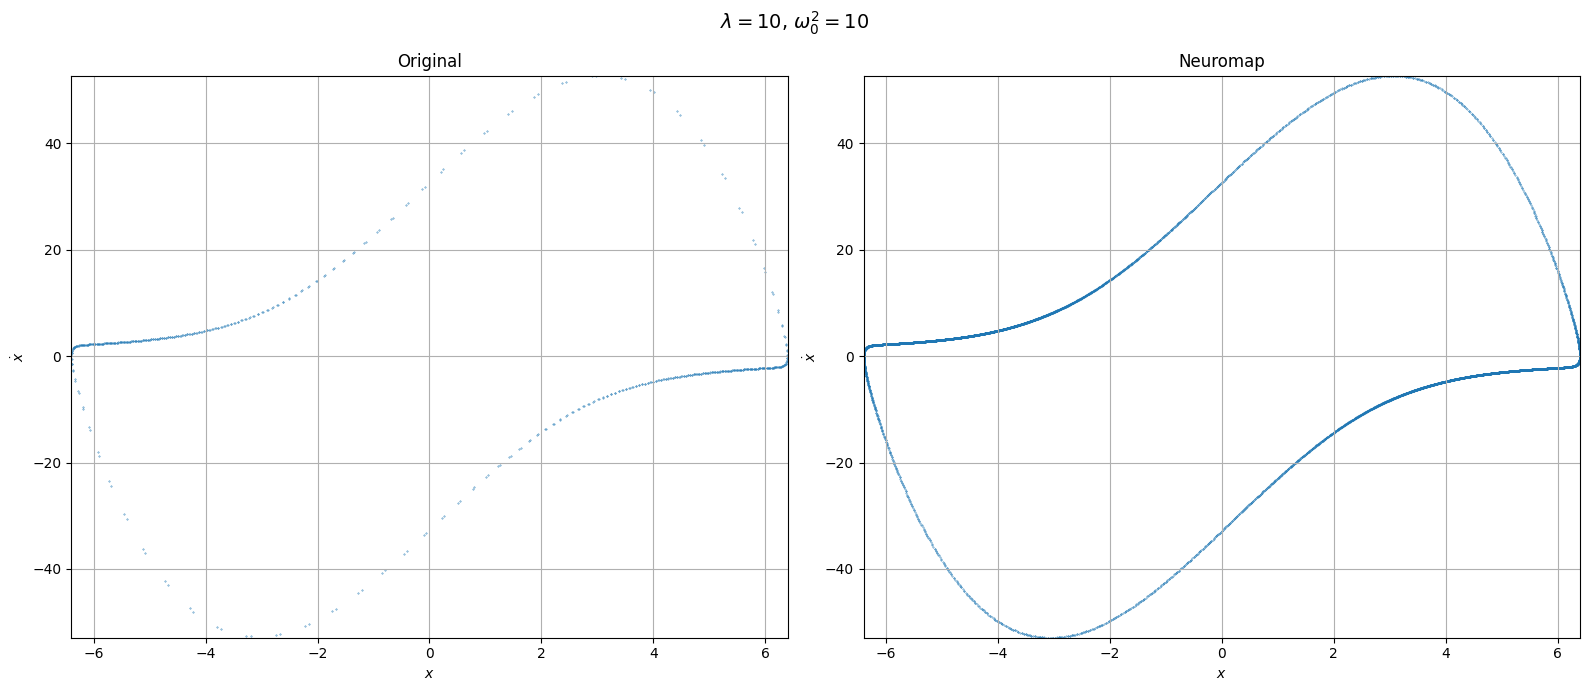

In [4]:
u0 = [0.5, 0.7]
p = [10, 10]

nm_traj = model.simulate(u0=u0, p=p, n_steps=10000)[2000:]
ode_traj = get_attractor_trajectory(van_der_pol_rk4, van_der_pol_right_part, u0, p, 0.01, 50, 300, lambda x, y: x[1], lambda x, y: [0, 1])

caption = r'$\lambda=$' + str(p[0]) + r', $\omega_0^2=$' + str(p[1])
plot_compare(ode_traj, nm_traj, caption=caption)

### Карта максимальных амплитуд

Вычисление сетки (по строкам): 100%|██████████| 20/20 [00:18<00:00,  1.07it/s]


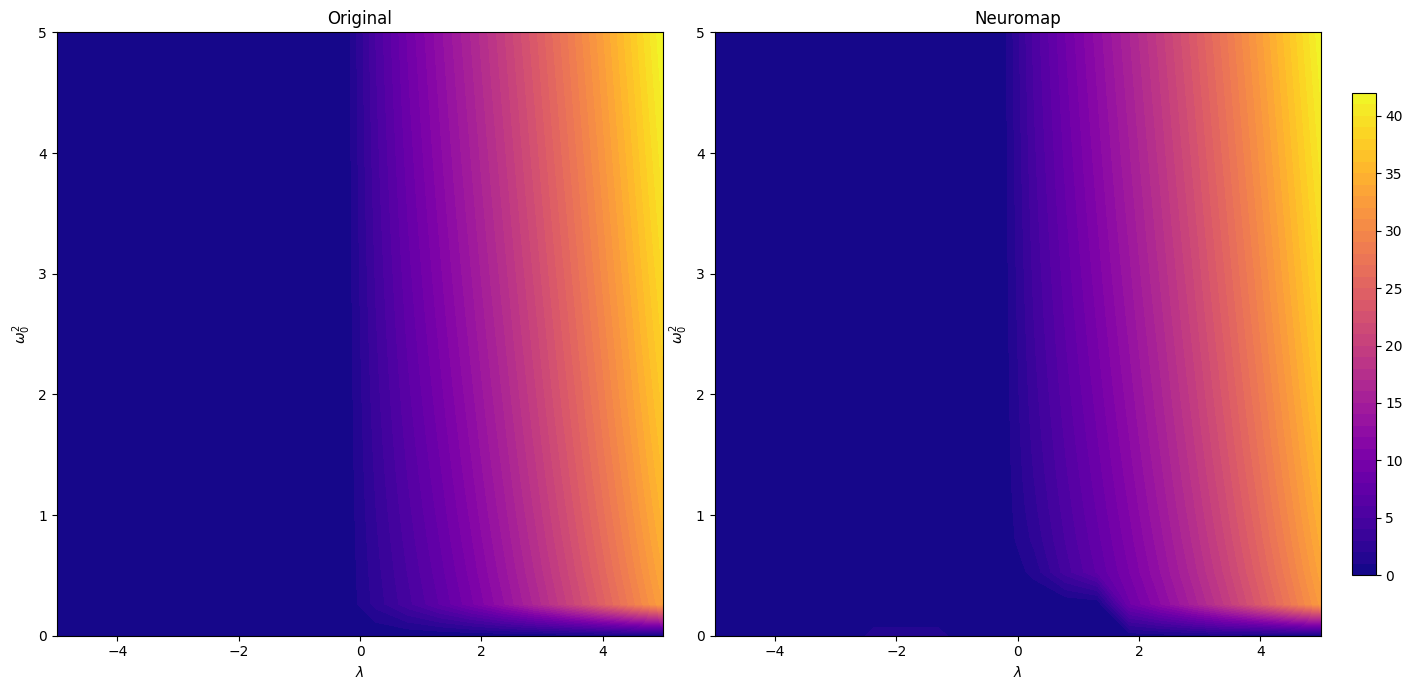

In [5]:
import numpy as np
from utils.trajectories import grid_of_amplitude
from utils.plots import plot_compare_heatmaps
from systems.van_der_pol_rk4 import van_der_pol_rk4

x = np.linspace(-5, 5, 20)
y = np.linspace(0, 5, 20)
u0 = [0.6, 0.7]

Z_nm = grid_of_amplitude(van_der_pol_rk4, u0, [x, y], 0.01, 2000, 8000, model=model)
Z_ode = grid_of_amplitude(van_der_pol_rk4, u0, [x, y], 0.01, 20, 20, secant_plane=lambda x, y: x[0],
            secant_plane_derivatives=lambda x, y: [1, 0], right_part=van_der_pol_right_part)
plot_compare_heatmaps(x, y, Z_ode, Z_nm, x_label=r'$\lambda$', y_label=r'$\omega_0^2$')

### Карта седел

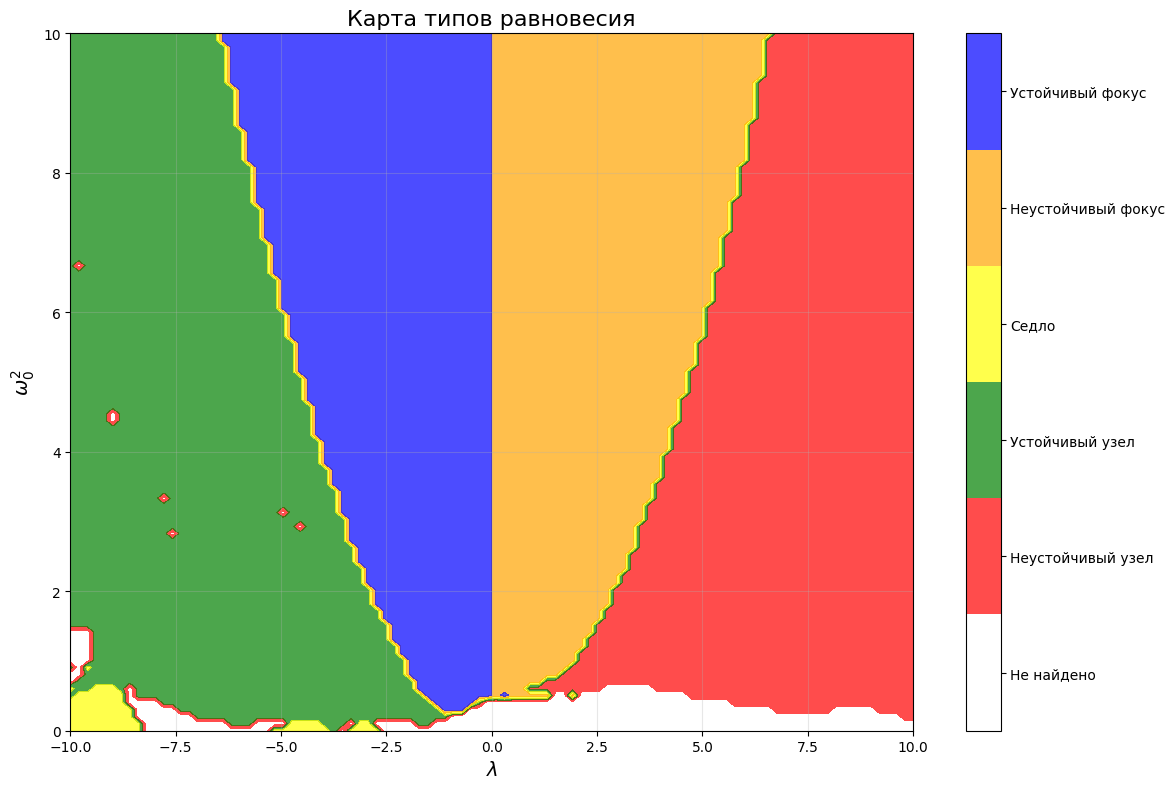

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def classify_multipliers(multipliers):
    mu1, mu2 = multipliers
    is_complex = np.iscomplex(mu1) or np.iscomplex(mu2)
    
    if is_complex:
        magnitude = np.abs(mu1)
        if magnitude < 1:
            return 5  # Устойчивый фокус
        else:
            return 4  # Неустойчивый фокус
    else:
        mu1_real, mu2_real = np.real(mu1), np.real(mu2)
        if abs(mu1_real) < 1 and abs(mu2_real) < 1:
            return 2  # Устойчивый узел
        elif abs(mu1_real) > 1 and abs(mu2_real) > 1:
            return 1  # Неустойчивый узел
        else:
            return 3  # Седло


def create_equilibrium_map_nn(model, lambda_vals, w0_sq_vals, bounds=[(-3, 3), (-3, 3)]):
    n_lambda = len(lambda_vals)
    n_w0 = len(w0_sq_vals)
    equilibrium_type = np.zeros((n_w0, n_lambda))
    
    for i, lambda_val in enumerate(lambda_vals):
        for j, w0_sq_val in enumerate(w0_sq_vals):
            p = [lambda_val, w0_sq_val]
            
            try:
                u_star, converged, result = model.find_fixed_point(
                    p=p, 
                    u0=np.array([0.0, 0.0]), 
                    tol=1e-6
                )
                
                if np.linalg.norm(result.fun) > 1e-5:
                    equilibrium_type[j, i] = 0
                    continue
                
                multipliers = model.compute_fixed_point_multipliers(u_star, p)
                eq_type = classify_multipliers(multipliers)
                equilibrium_type[j, i] = eq_type
                
            except Exception as e:
                print(f"Ошибка в точке ({lambda_val:.2f}, {w0_sq_val:.2f}): {e}")
                equilibrium_type[j, i] = 0
    
    return equilibrium_type


def plot_equilibrium_map(lambda_vals, w0_sq_vals, equilibrium_type, title="Карта типов равновесия"):
    type_labels = {
        1: 'Неустойчивый узел',
        2: 'Устойчивый узел', 
        3: 'Седло',
        4: 'Неустойчивый фокус',
        5: 'Устойчивый фокус'
    }
    colors = ['white', 'red', 'green', 'yellow', 'orange', 'blue']
    
    plt.figure(figsize=(12, 8))
    contour = plt.contourf(
        lambda_vals, w0_sq_vals, equilibrium_type, 
        levels=[-0.5, 0.5, 1.5, 2.5, 3.5, 4.5, 5.5], 
        colors=colors, 
        alpha=0.7
    )
    
    cbar = plt.colorbar(contour, ticks=[0, 1, 2, 3, 4, 5])
    cbar.ax.set_yticklabels(['Не найдено'] + [type_labels[i] for i in [1, 2, 3, 4, 5]])
    
    plt.xlabel(r'$\lambda$', fontsize=14)
    plt.ylabel(r'$\omega_0^2$', fontsize=14)
    plt.title(title, fontsize=16)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


lambda_vals = np.linspace(-10, 10, 100)
w0_sq_vals = np.linspace(0, 10, 100)

equilibrium_type_nn = create_equilibrium_map_nn(model, lambda_vals, w0_sq_vals)
plot_equilibrium_map(lambda_vals, w0_sq_vals, equilibrium_type_nn)